In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.columns', None) # biar kolom tidak terpotong
pd.set_option('display.float.format','{:.2f}'.format) #scientific notation

In [227]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [228]:
pip install google_play_scraper

In [229]:
from google_play_scraper import app



In [230]:
from google_play_scraper import Sort, reviews

In [231]:
from google_play_scraper import reviews, Sort
import pandas as pd

all_reviews = []
token = None

for i in range(13):  # 60 x 500 = 30.000
    result, token = reviews(
        'id.bmri.livin',
        lang='id',
        country='id',
        sort=Sort.NEWEST,
        count=500,
        continuation_token=token
    )

    all_reviews.extend(result)

    print(f"Batch {i+1}: {len(result)} reviews | Total: {len(all_reviews)}")

    if token is None:
        print("Tidak ada data berikutnya.")
        break

df = pd.DataFrame(all_reviews)

Batch 1: 500 reviews | Total: 500
Batch 2: 500 reviews | Total: 1000
Batch 3: 500 reviews | Total: 1500
Batch 4: 500 reviews | Total: 2000
Batch 5: 500 reviews | Total: 2500
Batch 6: 500 reviews | Total: 3000
Batch 7: 500 reviews | Total: 3500
Batch 8: 500 reviews | Total: 4000
Batch 9: 500 reviews | Total: 4500
Batch 10: 500 reviews | Total: 5000
Batch 11: 500 reviews | Total: 5500
Batch 12: 500 reviews | Total: 6000
Batch 13: 500 reviews | Total: 6500


### Maksimal mengambil 6500 data terupdate

In [233]:
# import data ke CSV
import pandas as pd

df.to_csv("livin_reviews14.csv", index=False)

print("CSV berhasil dibuat!")
print(df.head(2))

CSV berhasil dibuat!
                               reviewId      userName  \
0  c2564e0f-9f6f-4af9-b860-221034f425c1   Wahyu Nikoy   
1  97a9dd14-db97-4f7b-8407-455bca4fccf7  Mila Jamilah   

                                                                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8ocJCRzDHU2w-kUa4-TAy3066ko5kNRO8sQjIuKs-F7XyfzeOUQ=mo   
1  https://play-lh.googleusercontent.com/a/ACg8ocKx_itdyWAjnwXPZzyboDPZXGcjcTGOv-EAKmhju6QtETYsSQ=mo   

          content  score  thumbsUpCount reviewCreatedVersion  \
0  sangat membatu      5              0                3.8.0   
1           bagus      5              0                3.7.0   

                   at  \
0 2026-09-17 11:11:44   
1 2026-09-17 11:11:25   

                                                                                                                                                                                                                                 

In [234]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
# from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF
from nltk.tokenize import word_tokenize # tokenisasi
from nltk.corpus import stopwords # deteksi stopword
from nltk.stem import SnowballStemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [235]:
# Membaca data
df = pd.read_csv('livin_reviews11.csv')
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3d7bc146-31d0-498e-b685-f05c9d782e05,Umi Rahmawati,https://play-lh.googleusercontent.com/a/ACg8ocIgb7V6_1UgXd01umglGHsJP90968MkrcBgs_FDKIcThhJsCg=mo,berguna,5,0,3.7.0,2026-09-15 19:34:16,"Halo Sahabat @Umi Rahmawati, terima kasih atas review yang telah Sahabat berikan.\n\nSebagai informasi, Sahabat dapat memanfaatkan layanan Livin' Call by Mandiri Bebas Pulsa melalui aplikasi Livin’ by Mandiri untuk kemudahan dalam mengakses layanan kami. Tks~Romi",2026-09-15 19:37:51,3.7.0
1,0943f516-96d1-4697-b9cb-da13bf1e69b9,Hasban Nuzair,https://play-lh.googleusercontent.com/a/ACg8ocLTd_5XUuRFZaFDqXYw_moNSOtkjMXj2qzpRgpGoaKcO7A-1g=mo,one of the Best aplikasi for internet banking,5,0,3.7.0,2026-09-15 19:31:39,"Halo Sahabat Hasban Nuzair, terima kasih atas review yang telah diberikan.\n\nSebagai informasi, Sahabat dapat memanfaatkan layanan Livin' Call by Mandiri Bebas Pulsa melalui aplikasi Livin’ by Mandiri untuk kemudahan dalam mengakses layanan kami. Tks~Jojo",2026-09-15 19:32:58,3.7.0
2,033bdc94-59da-4558-8821-8bd2256669ea,Dimas Dipta,https://play-lh.googleusercontent.com/a/ACg8ocK7vvXX2NoVRGmX45z9oRN0t64v1FQXwnJsNO3ZvvzZyLU3NQ=mo,lemot,3,0,3.7.0,2026-09-15 19:31:29,"Halo Sahabat @Dimas Dipta, mohon maaf atas ketidaknyamanannya. Terkait kendala Sahabat mohon untuk dapat mengirimkan email ke mandiricare@bankmandiri.co.id atau dapat menghubungi Mandiri Call 14000 agar dapat dilakukan pengecekan. Tks~Feri",2026-09-15 19:33:49,3.7.0
3,c81f3dd5-cd45-46b8-8cc8-cc73f68d94a5,Gagal Berjuang,https://play-lh.googleusercontent.com/a-/ALV-UjV6PfNErFPBkIc8Le2tNVawXnAW4744ySdqR9foRENKjeNwcXE7,sangat baik,5,0,3.7.0,2026-09-15 19:29:01,"Halo Sahabat @Gagal Berjuang, terima kasih atas review yang telah diberikan.\n\nSebagai informasi, Sahabat dapat memanfaatkan layanan Livin' Call by Mandiri Bebas Pulsa melalui aplikasi Livin’ by Mandiri untuk kemudahan dalam mengakses layanan kami. Tks~Kale",2026-09-15 19:30:49,3.7.0
4,534c2be8-78c5-4f0f-a213-97a07e679f76,Alfi Yulianta,https://play-lh.googleusercontent.com/a-/ALV-UjWtM-v6t08HeT4qI6ias85WoZSYbqmW5N_FIPe52IYyxeehBbcM,tampilan menarik. mudah di pakai,5,0,3.7.0,2026-09-15 19:22:42,"Halo Sahabat @Alfi Yulianta, terima kasih atas review yang telah diberikan.\n\nSebagai informasi, Sahabat dapat memanfaatkan layanan Livin' call by Mandiri Bebas Pulsa melalui aplikasi Livin' by Mandiri untuk kemudahan dalam mengakses layanan kami. Tks~Vika",2026-09-15 19:37:31,3.7.0


In [236]:
df_2026 = df

### **a. Goal**

Dashboard ini bertujuan untuk **mengevaluasi persepsi dan pengalaman pengguna aplikasi Livin' by Mandiri** berdasarkan rating dan ulasan pengguna dari Google Play Store. Analisis dilakukan untuk mengetahui **perubahan sentimen pelanggan setelah adanya isu atau perubahan pada aplikasi**, serta mengidentifikasi aspek yang perlu **dipertahankan dan diperbaiki**.

### **b. Audience**

Audiens utama dashboard ini adalah:

- **Tim Manajemen/Business Team** sebagai pihak yang berkepentingan dalam mengevaluasi pengalaman dan kepuasan pengguna.
- **Software Analyst/Developer** untuk mengidentifikasi masalah pada aplikasi serta menentukan aspek yang perlu dikembangkan atau diperbaiki.
- **Tim Customer Experience** untuk memahami keluhan, kebutuhan, dan respons pengguna terhadap aplikasi.
- **Pengguna baru Livin' by Mandiri** untuk mengetahui pengalaman dan persepsi pengguna lain terhadap aplikasi.

### **c. Message**

Melalui dashboard, kita dapat menjawab beberapa pertanyaan:

1. **Bagaimana persepsi pelanggan terhadap aplikasi Livin' by Mandiri berdasarkan rating dan sentimen ulasan?**
2. **Apakah terdapat perubahan sentimen pelanggan setelah isu atau perubahan tertentu pada aplikasi?**
3. **Aspek apa yang mendapatkan respons positif dan perlu dipertahankan?**
4. **Aspek apa yang paling banyak dikeluhkan dan perlu diperbaiki?**

Untuk mendapatkan insight dari komentar pengguna, data Google Play Store yang terdiri dari **nama pengguna, rating, versi aplikasi, tanggal review, dan komentar** dianalisis menggunakan **Naive Bayes** untuk melakukan klasifikasi sentimen. Hasil klasifikasi kemudian digunakan untuk menganalisis **perubahan sentimen, isu yang dominan, serta aspek aplikasi yang perlu dipertahankan atau diperbaiki**.

## 
Dataset yang digunakan merupakan data review pengguna aplikasi **Livin' by Mandiri**. Dataset terdiri dari 11 kolom yang berisi informasi mengenai identitas review, isi ulasan, rating, waktu pemberian review, versi aplikasi, serta respons dari developer.

| Kolom | Deskripsi |
|---|---|
| `reviewId` | ID unik yang digunakan untuk mengidentifikasi setiap review pengguna. |
| `userName` | Nama pengguna yang memberikan review. |
| `userImage` | URL atau alamat gambar profil pengguna. |
| `content` | Isi atau teks review yang diberikan oleh pengguna. |
| `score` | Rating yang diberikan pengguna terhadap aplikasi dengan skala 1–5. |
| `thumbsUpCount` | Jumlah pengguna lain yang memberikan tanda helpful pada review tersebut. |
| `reviewCreatedVersion` | Versi aplikasi yang digunakan ketika review dibuat. |
| `at` | Tanggal dan waktu ketika review diberikan. |
| `replyContent` | Isi balasan dari developer terhadap review pengguna, jika tersedia. |
| `repliedAt` | Tanggal dan waktu ketika developer memberikan balasan terhadap review. |
| `appVersion` | Versi aplikasi yang tercatat pada data review. |

Text(0.5, 1.0, 'Rating pengguna terhadap aplikasi')

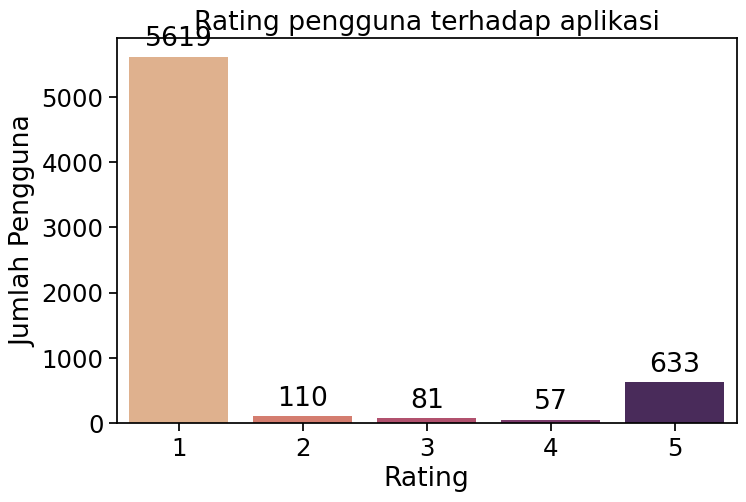

In [237]:
rating = df_2026.groupby('score')['userName'].count().reset_index(name='jumlah')
plt.figure(figsize=(8, 5))

fig = sns.barplot( x='score',
    y='jumlah',
    data=rating,
    hue='score',
    palette='flare',
    legend=False
)
for i in fig.containers:
    fig.bar_label(i, padding = 3)

plt.xlabel('Rating')
plt.ylabel('Jumlah Pengguna')
plt.title('Rating pengguna terhadap aplikasi')



## Data yang digunakan diambil dari 6500 data terupdate dalam periode 24 agustus 2025 - 15 September 2026. 

# Cleaning

In [238]:
def text_cleaning(text):
    text = text.lower()

    
    text = text.replace('..', ' ')
    text = text.replace('...', ' ')
    text = text.replace('....', ' ')
    
    text = text.encode('ascii', 'replace').decode('ascii') # remove non ASCII (emoticon, chinese word, .etc)
    text = text.replace(r'\d+', "") # remove digits
    text = text.translate(str.maketrans("","",string.punctuation)) #remove punctuation
    text = text.strip() # remove whitespace from the beginning and end
    text = re.sub(r'\s+',' ', text) # remove multiple whitespace

    return text

In [239]:
df['text_clean'] = df['content'].apply(lambda x: text_cleaning(x))

In [240]:
df[['content', 'text_clean']].head(10)

,content,text_clean
0,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot
3,sangat baik,sangat baik
4,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai
5,mantap,mantap
6,okeh,okeh
7,asal mau logi hp selalu mati,asal mau logi hp selalu mati
8,Penarikan tunai gampang dan TF juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang
9,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan QRIS juga.,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga


In [241]:
normalisasi =pd.read_csv('normalisasi.csv')

In [242]:
slang_dict = dict(zip(normalisasi['before'], normalisasi['after']))

In [243]:
def normalize_slang(text):
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return ' '.join(words)

In [244]:
df['Normalisasi'] = df['text_clean'].apply(normalize_slang)

In [245]:
df[['content','text_clean', 'Normalisasi']].head(11)

,content,text_clean,Normalisasi
0,berguna,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot
3,sangat baik,sangat baik,sangat baik
4,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah di pakai
5,mantap,mantap,mantap
6,okeh,okeh,okeh
7,asal mau logi hp selalu mati,asal mau logi hp selalu mati,asal mau logi hp selalu mati
8,Penarikan tunai gampang dan TF juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang
9,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan QRIS juga.,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga


# load kamus stopwords menggunakan tala

In [ ]:
# load kamus stopwords menggunakan tala

tala = pd.read_csv('StopWords_Tala.csv')

In [ ]:

stopwords_tala = set(tala['LEMA'])



In [ ]:

# membuat function untuk mengaplikasikan kamus tala ke dalam data teks
def remove_stopwords(text):
    return ' '.join([i for i in text if i not in stopwords_tala])

In [ ]:
df['tweet_tala'] = df['Normalisasi'].apply(lambda x: remove_stopwords(x.split()))
df[['content','text_clean', 'Normalisasi','tweet_tala']].head(10
                                                              )

,content,text_clean,Normalisasi,tweet_tala
0,berguna,berguna,berguna,berguna
1,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot,lemot
3,sangat baik,sangat baik,sangat baik,baik
4,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah pakai
5,mantap,mantap,mantap,mantap
6,okeh,okeh,okeh,okeh
7,asal mau logi hp selalu mati,asal mau logi hp selalu mati,asal mau logi hp selalu mati,logi hp mati
8,Penarikan tunai gampang dan TF juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang,penarikan tunai gampang tf gampang
9,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan QRIS juga.,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga,gak susah berniaga gk bawa uang ambil via aplikasi qris


# Steamer

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem(text):
    """
    :param text:
    :return: stemmed text
    """
    return stemmer.stem(text)

In [ ]:

df['tweet_stem_tala'] = df['tweet_tala'].apply(lambda x: stem(x))

In [ ]:
df[['content','text_clean', 'Normalisasi','tweet_tala','tweet_stem_tala']].head(10
                                                              )

,content,text_clean,Normalisasi,tweet_tala,tweet_stem_tala
0,berguna,berguna,berguna,berguna,guna
1,one of the Best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking,one of the best aplikasi for internet banking
2,lemot,lemot,lemot,lemot,lot
3,sangat baik,sangat baik,sangat baik,baik,baik
4,tampilan menarik. mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah di pakai,tampilan menarik mudah pakai,tampil tarik mudah pakai
5,mantap,mantap,mantap,mantap,mantap
6,okeh,okeh,okeh,okeh,okeh
7,asal mau logi hp selalu mati,asal mau logi hp selalu mati,asal mau logi hp selalu mati,logi hp mati,log hp mati
8,Penarikan tunai gampang dan TF juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang,penarikan tunai gampang dan tf juga sangat gampang,penarikan tunai gampang tf gampang,tari tunai gampang tf gampang
9,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan QRIS juga.,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga,gak susah buat berniaga dan walau gk bawa uang bisa ambil via aplikasi dan qris juga,gak susah berniaga gk bawa uang ambil via aplikasi qris,gak susah niaga gk bawa uang ambil via aplikasi qris


# Klasifikasi berdasarkan rating

In [246]:
def rating_to_sentiment(score):
    if score <= 3:
        return 'Negative'
    else:
        return 'Positive'

df['sentiment'] = df['score'].apply(rating_to_sentiment)

# Train Test

In [247]:
X = df['Normalisasi']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TFIDF

In [248]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Menggunakan Logistic Regression

In [249]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(
    classification_report(
        y_test,
        lr_pred,
        digits=3
    )
)

Accuracy: 0.9246153846153846
              precision    recall  f1-score   support

    Negative      0.965     0.950     0.958      1162
    Positive      0.628     0.710     0.667       138

    accuracy                          0.925      1300
   macro avg      0.797     0.830     0.812      1300
weighted avg      0.929     0.925     0.927      1300



In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    
    "Naive Bayes": MultinomialNB(),
    
    "Linear SVM": LinearSVC(
        class_weight='balanced',
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

results = []

for name, model in models.items():
    
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred)
    })
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(
        y_test,
        pred,
        digits=3
    ))

Logistic Regression
              precision    recall  f1-score   support

    Negative      0.965     0.950     0.958      1162
    Positive      0.628     0.710     0.667       138

    accuracy                          0.925      1300
   macro avg      0.797     0.830     0.812      1300
weighted avg      0.929     0.925     0.927      1300

Naive Bayes
              precision    recall  f1-score   support

    Negative      0.922     0.998     0.959      1162
    Positive      0.952     0.290     0.444       138

    accuracy                          0.923      1300
   macro avg      0.937     0.644     0.702      1300
weighted avg      0.925     0.923     0.904      1300

Linear SVM
              precision    recall  f1-score   support

    Negative      0.957     0.964     0.961      1162
    Positive      0.677     0.638     0.657       138

    accuracy                          0.929      1300
   macro avg      0.817     0.801     0.809      1300
weighted avg      0.928     0.9

## dengan pertimbangan nilai f1 terbaik pada prediksi poitif maka kami mengambil Logistic Regression

In [255]:
# Probabilitas Positive
y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Coba threshold 0.6
lr_pred_threshold = np.where(
    y_prob >= 0.6,
    'Positive',
    'Negative'
)


print("Threshold 0.6")
print(classification_report(
    y_test,
    lr_pred_threshold,
    digits=3
))

Threshold 0.6
              precision    recall  f1-score   support

    Negative      0.956     0.968     0.962      1162
    Positive      0.699     0.623     0.659       138

    accuracy                          0.932      1300
   macro avg      0.828     0.796     0.810      1300
weighted avg      0.929     0.932     0.930      1300



### Evaluasi Model dengan Threshold 0.6

Berdasarkan hasil evaluasi dengan **threshold 0.6**, model menghasilkan **accuracy sebesar 93,3%**. Hasil ini menunjukkan bahwa model mampu mengklasifikasikan sebagian besar data testing dengan benar.

Pada kelas **Negative**, model memperoleh:
- **Precision = 95,7%**
- **Recall = 96,9%**
- **F1-Score = 96,3%**
- **Support = 1.162 data**

Hasil tersebut menunjukkan bahwa model memiliki performa yang sangat baik dalam mengidentifikasi sentimen Negative.

Sementara itu, pada kelas **Positive**, model memperoleh:
- **Precision = 70,7%**
- **Recall = 63,0%**
- **F1-Score = 66,7%**
- **Support = 138 data**

Performa kelas Positive masih lebih rendah dibandingkan kelas Negative. Hal ini berkaitan dengan **ketidakseimbangan jumlah data**, di mana terdapat **1.162 data Negative dan hanya 138 data Positive** pada data testing. Dengan jumlah data Positive yang jauh lebih sedikit, model memiliki lebih banyak contoh untuk mempelajari pola sentimen Negative dibandingkan Positive.

Pada **macro average**, model memperoleh F1-score sebesar **81,5%**, sedangkan **weighted average** menghasilkan F1-score sebesar **93,1%**. Perbedaan ini terjadi karena weighted average mempertimbangkan jumlah data pada setiap kelas, sehingga kelas Negative yang memiliki jumlah data jauh lebih besar memberikan pengaruh yang lebih besar terhadap nilai tersebut.


In [256]:
X_all_tfidf = tfidf.transform(df['content'])

y_prob_all = lr_model.predict_proba(X_all_tfidf)[:, 1]

df['ml_sentiment'] = np.where(
    y_prob_all >= 0.6,
    'Positive',
    'Negative'
)

In [250]:
X_all_tfidf = tfidf.transform(df['content'])

df['ml_sentiment'] = lr_model.predict(X_all_tfidf)

In [257]:
pd.crosstab(
    df['sentiment'],
    df['ml_sentiment']
)

ml_sentiment,Negative,Positive
sentiment,,
Negative,5671,139
Positive,120,570


In [258]:
df['sesuai'] = df['sentiment'] == df['ml_sentiment']

df['hasil'] = df['sesuai'].map({
    True: 'Sesuai',
    False: 'Tidak Sesuai'
})

In [259]:
df['hasil'].value_counts()

hasil
Sesuai          6241
Tidak Sesuai     259
Name: count, dtype: int64

In [184]:
df['hasil'].value_counts(normalize=True) * 100

hasil
Sesuai         96.02
Tidak Sesuai    3.98
Name: proportion, dtype: float64

### Analisis Hasil Klasifikasi

Berdasarkan hasil klasifikasi, terdapat **6.260 data (96,31%)** yang termasuk kategori **Sesuai**, sedangkan **240 data (3,69%)** termasuk kategori **Tidak Sesuai**.

Hasil pengecekan terhadap data yang tidak sesuai menunjukkan bahwa terdapat beberapa kondisi yang dapat menyebabkan perbedaan antara hasil klasifikasi dan label berdasarkan rating.

- **Sarkasme:** Terdapat beberapa komentar yang menggunakan sarkasme sehingga makna sebenarnya berbeda dengan makna literal dari teks. Kondisi ini dapat menjadi tantangan bagi model dalam menentukan sentimen.
- **Rating dan komentar tidak selalu konsisten:** Ditemukan beberapa review dengan rating yang tergolong baik, tetapi isi komentarnya menunjukkan sentimen negatif. Berdasarkan pengecekan manual, terdapat kasus yang mengindikasikan pengguna kemungkinan **salah memberikan rating**.
- **Sentimen berdasarkan teks memberikan informasi tambahan:** Perbedaan antara rating dan isi komentar menunjukkan bahwa rating tidak selalu sepenuhnya merepresentasikan sentimen yang disampaikan pengguna. Oleh karena itu, analisis teks dapat digunakan untuk memperoleh pemahaman yang lebih mendalam mengenai persepsi pengguna.

In [185]:
df.to_csv("Hasil_ML2.csv", index=False)

print("CSV berhasil dibuat!")
print(df.head())

CSV berhasil dibuat!
                               reviewId        userName  \
0  3d7bc146-31d0-498e-b685-f05c9d782e05   Umi Rahmawati   
1  0943f516-96d1-4697-b9cb-da13bf1e69b9   Hasban Nuzair   
2  033bdc94-59da-4558-8821-8bd2256669ea     Dimas Dipta   
3  c81f3dd5-cd45-46b8-8cc8-cc73f68d94a5  Gagal Berjuang   
4  534c2be8-78c5-4f0f-a213-97a07e679f76   Alfi Yulianta   

                                                                                           userImage  \
0  https://play-lh.googleusercontent.com/a/ACg8ocIgb7V6_1UgXd01umglGHsJP90968MkrcBgs_FDKIcThhJsCg=mo   
1  https://play-lh.googleusercontent.com/a/ACg8ocLTd_5XUuRFZaFDqXYw_moNSOtkjMXj2qzpRgpGoaKcO7A-1g=mo   
2  https://play-lh.googleusercontent.com/a/ACg8ocK7vvXX2NoVRGmX45z9oRN0t64v1FQXwnJsNO3ZvvzZyLU3NQ=mo   
3  https://play-lh.googleusercontent.com/a-/ALV-UjV6PfNErFPBkIc8Le2tNVawXnAW4744ySdqR9foRENKjeNwcXE7   
4  https://play-lh.googleusercontent.com/a-/ALV-UjWtM-v6t08HeT4qI6ias85WoZSYbqmW5N_FIPe52IYyxeehBbcM   


In [186]:
df_Neg = df_2026[(df_2026['ml_sentiment']=="Negative") &
    (df_2026['hasil'] == 'Sesuai')]


In [187]:
df_Pos = df_2026[(df_2026['ml_sentiment']=="Positive") &
    (df_2026['hasil'] == 'Sesuai')]

# Tidak ingin berfokus pada kata hubung atau domain seperti nama bank

In [199]:
stopwords_en = {
    'aplikasi', 'app', 'apps',
    'livin', 'mandiri', 'bank',
    'g', 'k', 's', 'x', 'e',
    'nih', 'tuh', 'deh', 'sih','ga','gak','no','not','tp','tdk','dah','that','bgt', 'ama',
    'ah',
    'bikin',
    'coba',
    'gitu',
    'kasih',
    'mas',
    'gue',
    'gw',
    'tau',
    
    
    'the', 'to', 'i', 'it', 'and', 'is', 'in',
    'my', 'this', 'for', 'a', 'an', 'of',
    'on', 'with', 'by', 'you', 'your', 'me',
    'up', 'out', 'at', 'from', 'or', 'but',
    'very', 'just', 'all', 'more', 'most',
    'when', 'what', 'why', 'how',
    'have', 'has', 'been', 'was', 'are',
    'be', 'do', 'does', 'did','the','lot','even','gk','bs','bgt','its','bs','udah'
}


In [200]:
def remove_stopwords(text):
    return ' '.join(
        word for word in text.split()
        if word not in stopwords_en
    )

In [201]:
df_Neg['text_no_stopword'] = df_Neg['tweet_stem_tala'].apply(remove_stopwords)

C:\Users\cacab\AppData\Local\Temp\ipykernel_4736\1193599246.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Neg['text_no_stopword'] = df_Neg['tweet_stem_tala'].apply(remove_stopwords)


In [202]:
df_Pos['text_no_stopword'] = df_Pos['tweet_stem_tala'].apply(remove_stopwords)

C:\Users\cacab\AppData\Local\Temp\ipykernel_4736\1333787869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Pos['text_no_stopword'] = df_Pos['tweet_stem_tala'].apply(remove_stopwords)


In [203]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)')
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [204]:
kamus_clean_neg = kamus(df_Neg['text_no_stopword'])
kamus_clean_Pos = kamus(df_Pos['text_no_stopword'])

# Hasil 

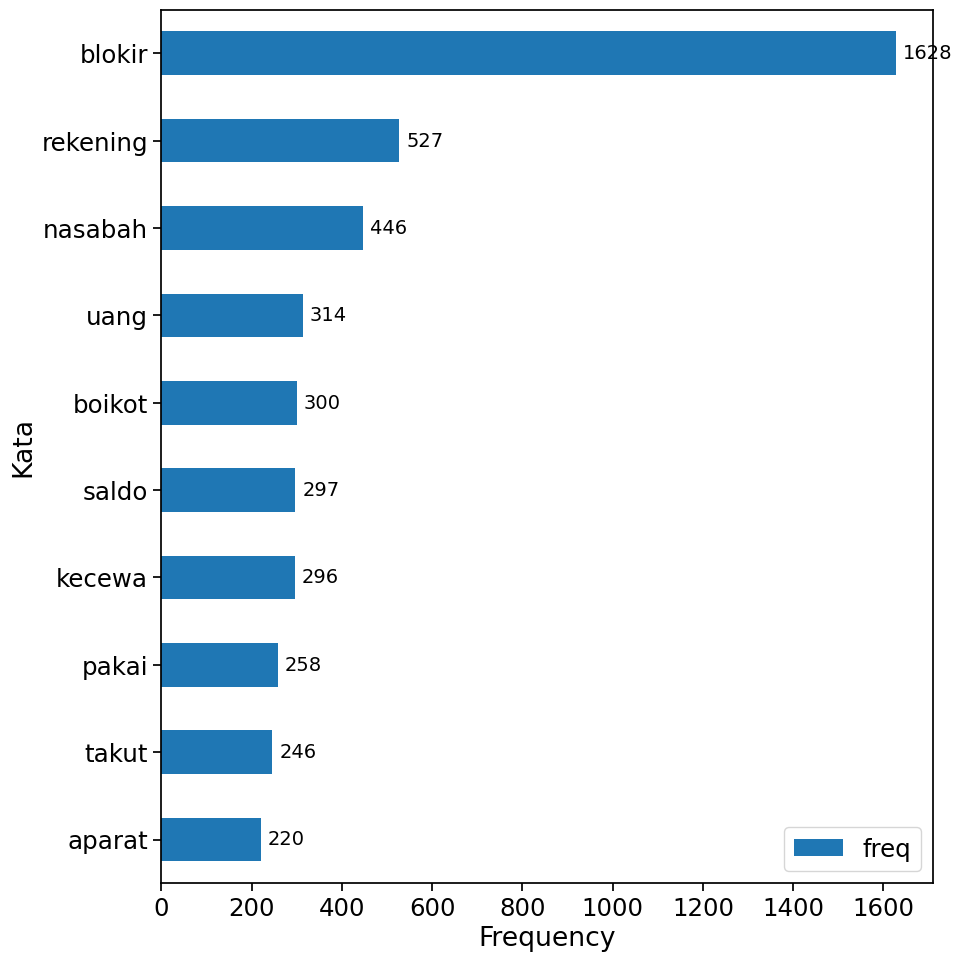

In [205]:

sns.set_context(context='notebook', font_scale=1.6)

ax = kamus_clean_neg[:10].sort_values(
    by='freq',
    ascending=True
).plot(
    kind='barh',
    figsize=(10,10)
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=14
)

plt.xlabel('Frequency')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

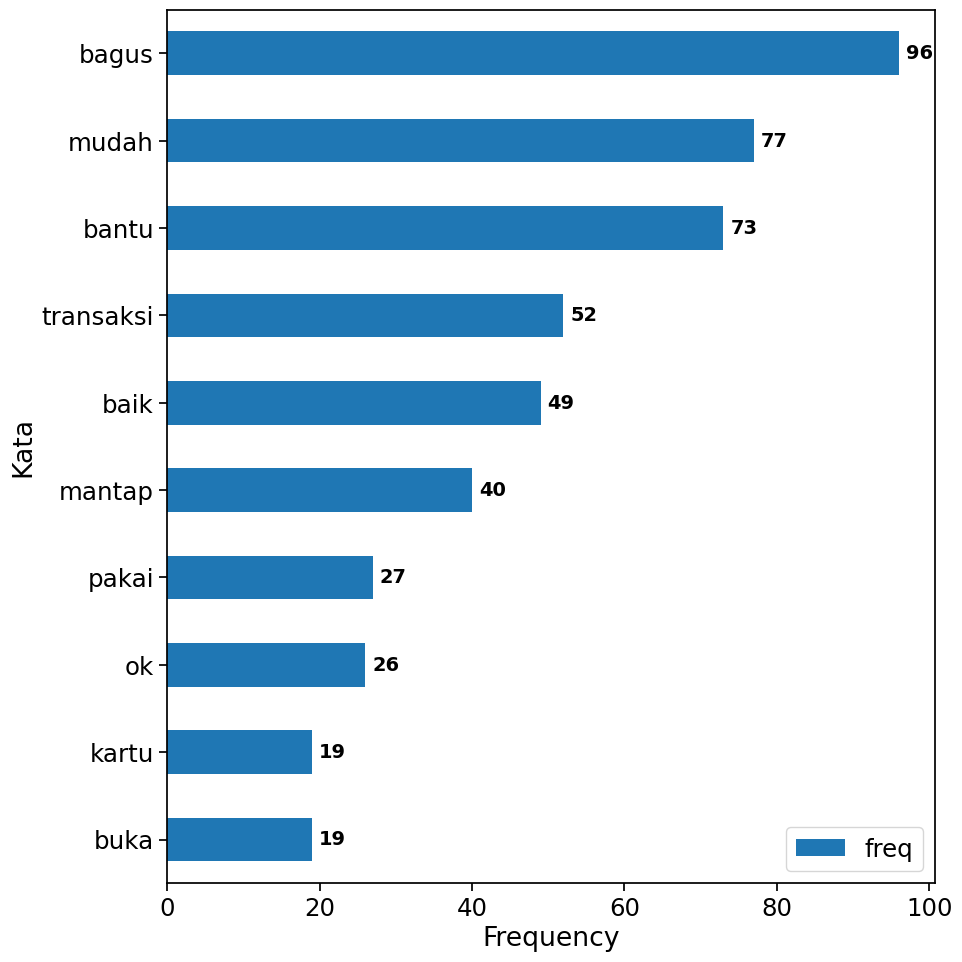

In [206]:
sns.set_context(context='notebook', font_scale=1.6)

ax = kamus_clean_Pos[:10].sort_values(
    by='freq',
    ascending=True
).plot(
    kind='barh',
    figsize=(10,10)
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Frequency')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

In [207]:
def plot_cloud(wordcloud):
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

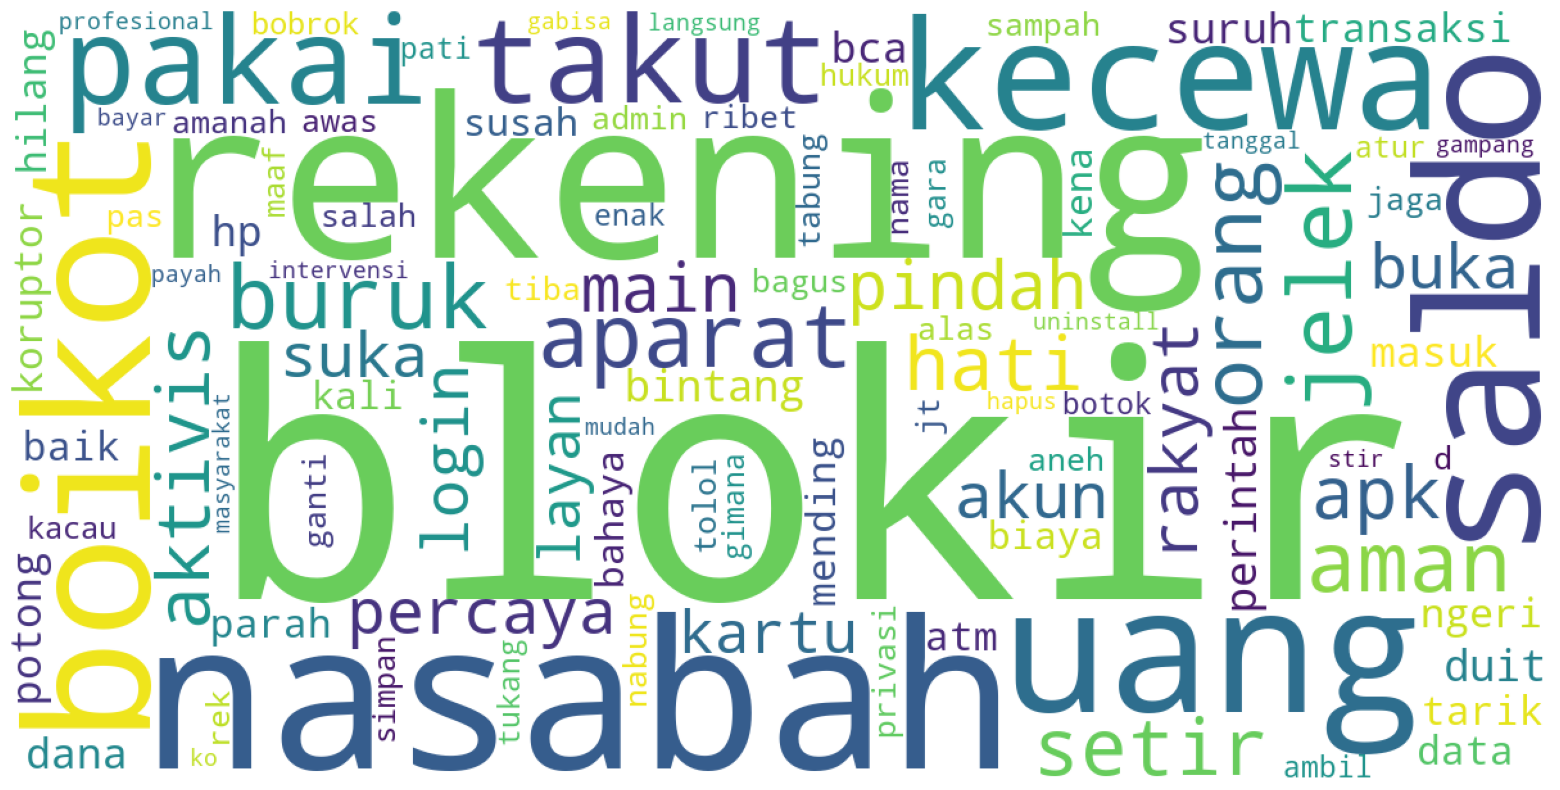

In [210]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil 50 kata dengan frekuensi tertinggi
hasil = kamus_clean_neg.head(150)

# Ubah menjadi dictionary: kata -> frekuensi
frekuensi = hasil['freq'].to_dict()

word_cloud_neg = WordCloud(
    background_color='white',
    width=1200,
    height=600,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=8
).generate_from_frequencies(frekuensi)

plot_cloud(word_cloud_neg)


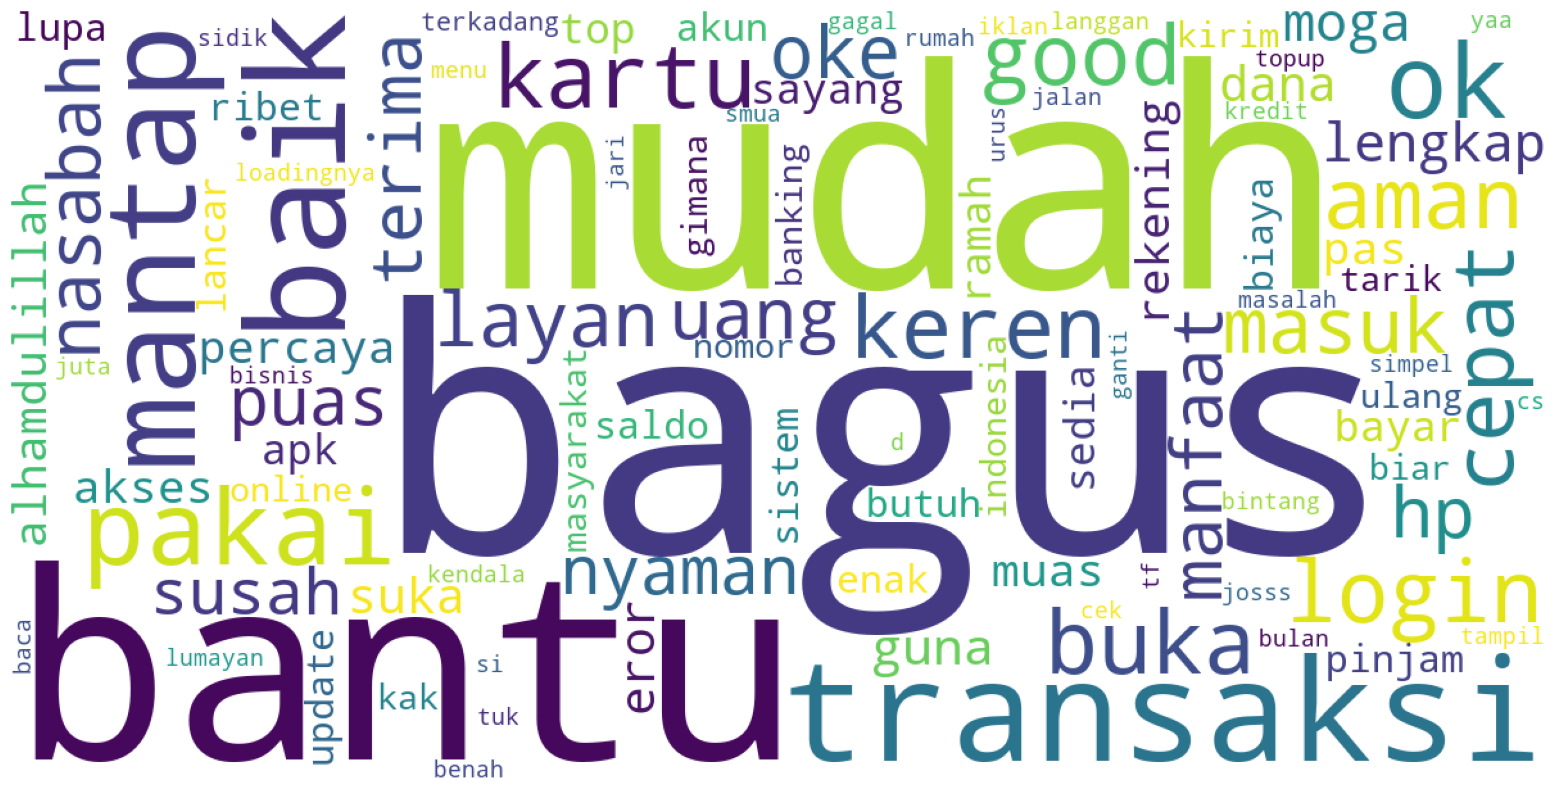

In [212]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil 50 kata dengan frekuensi tertinggi
hasil2 = kamus_clean_Pos.head(100)

# Ubah menjadi dictionary: kata -> frekuensi
frekuensi = hasil2['freq'].to_dict()

word_cloud_pos = WordCloud(
      background_color='white',
    width=1200,
    height=600,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=8
).generate_from_frequencies(frekuensi)

plot_cloud(word_cloud_pos)

### Business Questions & Insights

#### 1. Bagaimana persepsi pelanggan terhadap aplikasi Livin' by Mandiri berdasarkan rating dan sentimen ulasan?

Persepsi pelanggan terhadap Livin' by Mandiri dapat dilihat dari sentimen pada ulasan pengguna. Hasil analisis menunjukkan adanya sentimen Positive dan Negative. Pada review Positive, pengguna banyak menyampaikan pengalaman terkait **kemudahan, keamanan, kenyamanan, dan kemudahan melakukan transaksi**.

Sementara itu, pada review Negative terdapat dua jenis pembahasan, yaitu **keluhan terkait penggunaan aplikasi** dan **respons pelanggan terhadap isu A**. Kata seperti **`boikot`**, **`aparat`**, **`rekening`**, dan **`blokir`** perlu dipisahkan karena kemunculannya berkaitan dengan isu A, bukan semata-mata menunjukkan masalah teknis aplikasi.

#### 2. Apakah terdapat perubahan sentimen pelanggan setelah isu A?

Hasil analisis menunjukkan bahwa **isu A turut muncul dalam review Negative**, yang ditandai dengan munculnya kata seperti **`boikot`**, **`aparat`**, **`rekening`**, dan **`blokir`**.

Hal ini menunjukkan adanya **respons pelanggan terhadap isu A yang tercermin dalam ulasan aplikasi**. Namun, untuk menyatakan seberapa besar dampaknya terhadap sentimen pelanggan, perlu dilakukan perbandingan **periode sebelum dan sesudah isu A**, misalnya berdasarkan jumlah review dan proporsi sentimen.

#### 3. Aspek apa yang mendapatkan respons positif dan perlu dipertahankan?

Berdasarkan review Positive, aspek yang mendapatkan respons positif antara lain **kemudahan penggunaan, keamanan, kenyamanan, serta kemudahan dalam melakukan transaksi**.

Kata seperti **`mudah`**, **`gampang`**, **`aman`**, **`nyaman`**, **`bagus`**, dan **`bantu`** menunjukkan aspek-aspek yang dapat dipertahankan oleh pengelola aplikasi.

#### 4. Aspek apa yang paling banyak dikeluhkan dan perlu diperbaiki?

Untuk menentukan masalah aplikasi yang perlu diperbaiki, kata-kata yang berkaitan dengan **isu A** perlu dipisahkan terlebih dahulu dari keluhan teknis atau operasional.

Setelah mengeluarkan konteks isu A, keluhan yang berkaitan dengan aplikasi antara lain mencakup **login, transaksi, pembayaran, rekening, kartu, akses, serta proses yang dianggap sulit atau ribet**.

Dengan demikian, perbaikan dapat difokuskan pada **stabilitas, kemudahan akses, proses login, transaksi, dan layanan perbankan dalam aplikasi**, sementara respons yang muncul akibat isu A dianalisis sebagai **faktor eksternal yang memengaruhi sentimen pelanggan**.